<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

# Luna Marcelo — Aprendizaje Profundo — TP1 — Cohorte 24

Notebook de entrega según consigna del curso (desarrollo en celdas, compatible con Google Colab).

</div>


<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

La siguiente celda **importa** las bibliotecas base: **NumPy**, **SciPy** y **Matplotlib** (gráficos de la consigna). **Resultado esperado:** ejecución sin errores y mensajes de versión útiles para reproducibilidad en Colab.

</div>


In [127]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", mpl.__version__)

NumPy: 2.0.2
SciPy: 1.16.3
Matplotlib: 3.10.0


<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

### Dataset sintético

Según la consigna, **`x`** es un vector unidimensional con **`n ≥ 200`** puntos generados con **`np.linspace(ini, fin, n)`** en un intervalo **simétrico** \([ini, fin]\). El objetivo **`y`** sigue \(y = f(x) + \text{ruido}\), con \(f\) **no lineal** y ruido vía **`np.random`**.

La celda de código que sigue define **`_x`** e **`_y`**, que se usan en todo el notebook como datos de entrenamiento. La forma de \(f\) es **dominante tipo sigmoide** (en la práctica una **\(\tanh\)** escalada: curva en S acotada, familia equivalente a una sigmoide para este ejercicio) **más una perturbación trigonométrica pequeña** (\(\sin\)) para cumplir la combinación de no linealidades sin volver el target demasiado difícil para una sola \(\hat{y}=\tanh(wx+b)\).

**Resultado esperado:** arrays NumPy `_x`, `_y` de longitud `n`, listos para los optimizadores.

</div>

In [128]:
# --- Parámetros del muestreo en x (consigna: n >= 200, linspace en rango simétrico) ---
n = 250
ini, fin = -4.0, 4.0
_x = np.linspace(ini, fin, n)

# --- Señal determinista: parte dominante "tipo sigmoide" + oscilación pequeña ---
# La tangente hiperbólica tanh(k*x) es acotada y en forma de S (misma familia de no linealidad
# que una sigmoide logística, adecuada como término principal suave).
A = 1.0
k = 0.8  # pendiente de la S; valores ~0.5–1 mantienen la transición visible en [-4, 4]

# Perturbación trigonométrica: |B| debe ser claramente menor que |A| para no dominar la forma.
B = 0.2
omega = 1.5  # frecuencia moderada (evita muchas oscilaciones en el intervalo)

senal = A * np.tanh(k * _x) + B * np.sin(omega * _x)

# --- Ruido aleatorio (np.random): ruido gaussiano i.i.d. centrado ---
SEMILLA_RUIDO_DATASET = 42  # fija el ruido entre ejecuciones; cambiar para otra realización
np.random.seed(SEMILLA_RUIDO_DATASET)
sigma = 0.05  # desviación típica del ruido (orden 0.02–0.08 suele ser razonable)
ruido = sigma * np.random.randn(n)

_y = senal + ruido

print(f"n = {n}, x en [{ini}, {fin}], forma _x = {_x.shape}, forma _y = {_y.shape}")
print(f"Rango aprox. de y: [{_y.min():.4f}, {_y.max():.4f}]")

n = 250, x en [-4.0, 4.0], forma _x = (250,), forma _y = (250,)
Rango aprox. de y: [-1.1222, 1.1201]


<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

### Hiperparámetros para comparativas

Acuerdo para los experimentos del TP (gradiente descendente y, más adelante, otros optimizadores): **100 épocas** y tres **tasas de aprendizaje** \(0{,}1\), \(0{,}01\) y \(0{,}001\). Conviene definirlos como **variables en una sola celda** para no repetir números en el código, poder ajustarlos después sin buscar literales y dejar constancia en el notebook de qué valores se usaron.

La siguiente celda define **`EPOCAS_COMPARATIVA`** y **`TASAS_APRENDIZAJE`**; **resultado esperado:** valores impresos. La correspondencia **η → color** para los gráficos está en la celda que sigue a esa. La semilla y \((w_0,b_0)\) compartidos se fijan más adelante.

</div>


In [129]:
# Comparativa según consigna (modificar solo aquí si hace falta otro experimento)
EPOCAS_COMPARATIVA = 100
TASAS_APRENDIZAJE = (0.1, 0.01, 0.001)

print(f"Épocas: {EPOCAS_COMPARATIVA}")
print(f"Tasas de aprendizaje: {TASAS_APRENDIZAJE}")


Épocas: 100
Tasas de aprendizaje: (0.1, 0.01, 0.001)


<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

### Colores por learning rate (gráficos)

La siguiente celda define **`COLORES_LEARNING_RATE`**: un color fijo por cada \(\eta\) en `TASAS_APRENDIZAJE`, para que GD, Adam y otros gráficos compartan la misma leyenda visual.

**Resultado esperado:** diccionario listo para usar en `plt.plot(..., color=COLORES_LEARNING_RATE[_eta])` (requiere haber ejecutado antes la celda de hiperparámetros).

</div>

In [130]:
# Misma correspondencia η → color en todos los gráficos (GD, Adam, etc.)
COLORES_LEARNING_RATE = dict(zip(TASAS_APRENDIZAJE, ("C0", "C1", "C2")))

<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

### Red neuronal de una sola conexión

La siguiente celda define la **capa** con un único peso \(w\) y sesgo \(b\): primero \(z = w x + b\) (vectorizado sobre \(m\) muestras), luego \(\hat{y} = \tanh(z)\). También define el **error cuadrático medio** \(J(w,b)=\frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i-y_i)^2\).

**Resultado esperado:** funciones reutilizables (`preactivacion`, `forward`, `coste`, `inicializar_parametros_aleatorios`). Los vectores **`_x`** e **`_y`** son los del **dataset sintético** (celdas previas). Los valores iniciales \(w_0\) y \(b_0\) compartidos se fijan **después**, en la celda dedicada, para que todos los optimizadores partan del mismo punto.

</div>


In [131]:
def preactivacion(x: np.ndarray, w: float, b: float) -> np.ndarray:
    """Calcula z = w * x + b para cada muestra (x puede ser vector de forma (m,))."""
    x = np.asarray(x, dtype=float)
    return w * x + b


def activacion_tanh(z: np.ndarray) -> np.ndarray:
    """Aplica la tangente hiperbólica elemento a elemento (hat{y} = tanh(z))."""
    z = np.asarray(z, dtype=float)
    # NumPy proporciona tanh vectorizado compatible con el runtime de SciPy/Colab.
    return np.tanh(z)


def forward(x: np.ndarray, w: float, b: float) -> np.ndarray:
    """Propagación hacia adelante: devuelve hat{y} = tanh(w * x + b)."""
    z = preactivacion(x, w, b)
    return activacion_tanh(z)


def coste(y_hat: np.ndarray, y: np.ndarray) -> float:
    """
    Error cuadrático medio: J = (1/m) * sum_i (hat{y}_i - y_i)^2.
    """
    y_hat = np.asarray(y_hat, dtype=float)
    y = np.asarray(y, dtype=float)
    m = y_hat.size
    if m == 0:
        raise ValueError("Se necesita al menos una muestra (m >= 1).")
    return float(np.mean((y_hat - y) ** 2))


def coste_parametros(x: np.ndarray, y: np.ndarray, w: float, b: float) -> float:
    """J(w, b) usando los datos (x, y) y los parámetros actuales."""
    return coste(forward(x, w, b), y)


def inicializar_parametros_aleatorios() -> tuple[float, float]:
    """Inicializa w y b con distribución normal estándar (consigna: np.random.randn())."""
    return float(np.random.randn()), float(np.random.randn())

<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

### Parámetros iniciales \(w_0\) y \(b_0\) compartidos

Para comparar optimizadores de forma **consistente**, todos deben partir del **mismo** punto \((w_0,b_0)\). La siguiente celda usa `SEMILLA_PARAMETROS_INICIALES` y `inicializar_parametros_aleatorios()` para definir **`W_INICIAL`** y **`B_INICIAL`** una sola vez; más adelante cada optimizador los recibe como `w_inicial` y `b_inicial`.

**Resultado esperado:** valores impresos de `W_INICIAL`, `B_INICIAL` y una comprobación rápida de **forward** y **coste** con esos parámetros sobre `_x`, `_y`.

</div>


In [132]:
# Misma semilla => mismo (w0, b0) en todos los optimizadores y corridas comparables. Los valores son asignados más adelante.
SEMILLA_PARAMETROS_INICIALES = 0

np.random.seed(SEMILLA_PARAMETROS_INICIALES)
W_INICIAL, B_INICIAL = inicializar_parametros_aleatorios()
print("w0, b0 compartidos (usar en todos los optimizadores):", W_INICIAL, B_INICIAL)

_z = preactivacion(_x, W_INICIAL, B_INICIAL)
_y_hat = forward(_x, W_INICIAL, B_INICIAL)
_J = coste_parametros(_x, _y, W_INICIAL, B_INICIAL)
print("z =", _z)
print("hat{y} =", _y_hat)
print("J(w0, b0) =", _J)

w0, b0 compartidos (usar en todos los optimizadores): 1.764052345967664 0.4001572083672233
z = [-6.65605218 -6.59937579 -6.54269941 -6.48602303 -6.42934665 -6.37267027
 -6.31599389 -6.25931751 -6.20264113 -6.14596475 -6.08928837 -6.03261199
 -5.97593561 -5.91925923 -5.86258285 -5.80590647 -5.74923009 -5.69255371
 -5.63587732 -5.57920094 -5.52252456 -5.46584818 -5.4091718  -5.35249542
 -5.29581904 -5.23914266 -5.18246628 -5.1257899  -5.06911352 -5.01243714
 -4.95576076 -4.89908438 -4.842408   -4.78573162 -4.72905524 -4.67237885
 -4.61570247 -4.55902609 -4.50234971 -4.44567333 -4.38899695 -4.33232057
 -4.27564419 -4.21896781 -4.16229143 -4.10561505 -4.04893867 -3.99226229
 -3.93558591 -3.87890953 -3.82223315 -3.76555677 -3.70888038 -3.652204
 -3.59552762 -3.53885124 -3.48217486 -3.42549848 -3.3688221  -3.31214572
 -3.25546934 -3.19879296 -3.14211658 -3.0854402  -3.02876382 -2.97208744
 -2.91541106 -2.85873468 -2.8020583  -2.74538191 -2.68870553 -2.63202915
 -2.57535277 -2.51867639 -2.462

<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

## Consigna 

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para los 3 learning rates. Las 3 gráficas deben estar en el mismo plot para que la comparación visual sea más fácil.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

</div>


<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

### Gradiente descendente sobre \(J(w,b)\)

La siguiente celda implementa el **gradiente** de \(J\) respecto de \(w\) y \(b\) para \(\hat{y}=\tanh(wx+b)\) y costo **MSE**: usando \(\frac{\partial \hat{y}}{\partial z}=1-\hat{y}^2\) y la actualización \(w \leftarrow w - \eta \frac{\partial J}{\partial w}\), \(b \leftarrow b - \eta \frac{\partial J}{\partial b}\) (batch completo en cada época).

**Resultado esperado:** funciones `gradiente` y `entrenar_gradiente_descendente` (si no se pasan \(w\) y \(b\) iniciales, se obtienen con `inicializar_parametros_aleatorios`); una **corrida** por cada \(\eta\) que guarda el historial de \(J\) en `historiales_J_gd` y muestra \(J\) inicial/final por pantalla (la figura \(J\) vs época está en la siguiente sección).

</div>


In [133]:
def gradiente(x: np.ndarray, y: np.ndarray, w: float, b: float) -> tuple[float, float]:
    """
    Gradiente de J(w, b) para MSE y activación tanh (derivada respecto de z: 1 - hat{y}^2).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = x.size
    if m == 0:
        raise ValueError("Se necesita al menos una muestra (m >= 1).")

    y_hat = forward(x, w, b)
    residual = y_hat - y
    d_tanh = 1.0 - y_hat**2
    # factor por muestra: (2/m) * (hat{y}_i - y_i) * (1 - hat{y}_i^2)
    factor = (2.0 / m) * residual * d_tanh
    grad_w = float(np.dot(factor, x))
    grad_b = float(np.sum(factor))
    return grad_w, grad_b


def entrenar_gradiente_descendente(
    x: np.ndarray,
    y: np.ndarray,
    tasa_aprendizaje: float,
    epocas: int,
    w_inicial: float | None = None,
    b_inicial: float | None = None,
    semilla: int | None = None,
) -> tuple[float, float, list[float]]:
    """
    Minimiza J(w, b) con gradiente descendente (todo el batch por época).
    Si w_inicial y b_inicial son None, se inicializan con inicializar_parametros_aleatorios() (np.random.randn).
    Para comparar con otros optimizadores, pasar siempre el mismo par (p. ej. W_INICIAL, B_INICIAL).
    Devuelve (w, b, historial_J) donde historial_J[k] es el costo al inicio de la época k.
    """
    if semilla is not None:
        np.random.seed(semilla)

    if w_inicial is None and b_inicial is None:
        w, b = inicializar_parametros_aleatorios()
    elif w_inicial is None:
        w, b = float(np.random.randn()), float(b_inicial)
    elif b_inicial is None:
        w, b = float(w_inicial), float(np.random.randn())
    else:
        w, b = float(w_inicial), float(b_inicial)

    historial_J: list[float] = []
    for _ in range(epocas):
        historial_J.append(coste_parametros(x, y, w, b))
        g_w, g_b = gradiente(x, y, w, b)
        w -= tasa_aprendizaje * g_w
        b -= tasa_aprendizaje * g_b

    return w, b, historial_J


# --- GD por cada η: mismos W_INICIAL, B_INICIAL; historiales para el gráfico ---
historiales_J_gd: dict[float, list[float]] = {}
resultados_entrenamiento_gd: dict[float, tuple[float, float, float, float]] = {}  # w, b, J_ini, J_fin
for _eta in TASAS_APRENDIZAJE:
    _final_w, _final_b, _hist = entrenar_gradiente_descendente(
        _x,
        _y,
        tasa_aprendizaje=_eta,
        epocas=EPOCAS_COMPARATIVA,
        w_inicial=W_INICIAL,
        b_inicial=B_INICIAL,
        semilla=None,
    )
    historiales_J_gd[_eta] = _hist
    _J_fin = coste_parametros(_x, _y, _final_w, _final_b)
    resultados_entrenamiento_gd[_eta] = (_final_w, _final_b, _hist[0], _J_fin)
    print(f"η = {_eta:g} | J inicio (época 0) = {_hist[0]:.6f} | J final = {_J_fin:.6f} | w, b = {_final_w:.6f}, {_final_b:.6f}")

η = 0.1 | J inicio (época 0) = 0.031467 | J final = 0.018792 | w, b = 1.658632, 0.084866
η = 0.01 | J inicio (época 0) = 0.031467 | J final = 0.028456 | w, b = 1.759371, 0.345522
η = 0.001 | J inicio (época 0) = 0.031467 | J final = 0.031128 | w, b = 1.763715, 0.394346


<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

### Gráfico: costo \(J(w,b)\) vs número de época (GD)

La siguiente celda dibuja en **un solo gráfico** el historial de \(J\) frente al índice de época para cada **learning rate** en `TASAS_APRENDIZAJE`, usando los datos guardados en `historiales_J_gd` tras entrenar con gradiente descendente. El color de cada \(\eta\) viene de **`COLORES_LEARNING_RATE`** (igual que en el gráfico de Adam).

</div>


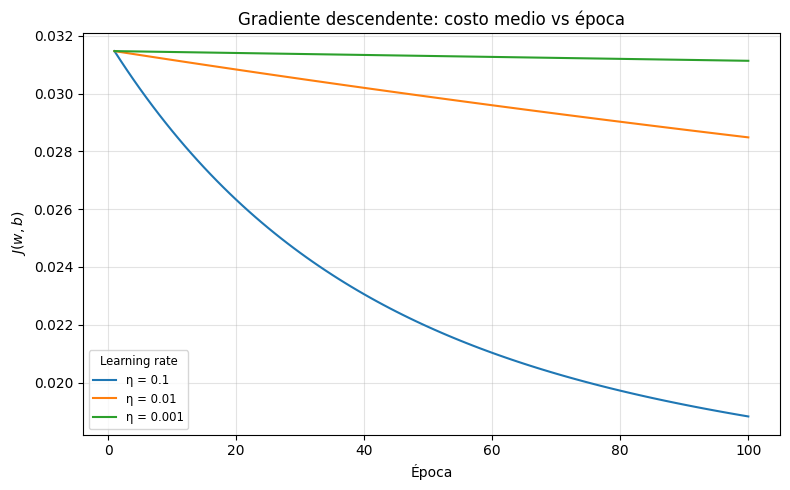

In [134]:
# Si aparece "plt is not defined", ejecutar antes la celda de imports (numpy + matplotlib).
import matplotlib.pyplot as plt
import numpy as np

epocas_eje = np.arange(1, EPOCAS_COMPARATIVA + 1)

plt.figure(figsize=(8, 5))
for _eta in TASAS_APRENDIZAJE:
    plt.plot(
        epocas_eje,
        historiales_J_gd[_eta],
        label=f"η = {_eta:g}",
        color=COLORES_LEARNING_RATE[_eta],
    )

plt.xlabel("Época")
plt.ylabel(r"$J(w,b)$")
plt.title("Gradiente descendente: costo medio vs época")
plt.legend(title="Learning rate", fontsize="small", title_fontsize="small")
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

### Optimizador Adam (full-batch)

La siguiente celda implementa **Adam** usando el **gradiente sobre todo el conjunto** en cada época (un solo paso por época, mismo tamaño de batch que el GD ya implementado). Momentos \(m_t\) y \(v_t\) se actualizan por componente para \(w\) y \(b\), con **corrección de sesgo** y \(\epsilon\) numérico.

**Nota:** no se modifica la celda del gradiente descendente; se reutiliza `gradiente`.

**Misma comparativa que GD (sin otros valores “por defecto” aparte):**
- **Learning rates:** solo los \(\eta\) de la tupla **`TASAS_APRENDIZAJE`** (los mismos tres que usa el bucle de GD).
- **Punto inicial:** **`w_inicial=W_INICIAL`** y **`b_inicial=B_INICIAL`** (el mismo \(w_0, b_0\) que el GD).
- **Épocas:** **`EPOCAS_COMPARATIVA`**, igual que GD.

**Resultado esperado:** función `entrenar_adam_full_batch` y un bloque que guarda `historiales_J_adam_full_batch` recorriendo **`TASAS_APRENDIZAJE`** con **`W_INICIAL`** / **`B_INICIAL`** y **`EPOCAS_COMPARATIVA`**.

</div>

In [135]:
def entrenar_adam_full_batch(
    x: np.ndarray,
    y: np.ndarray,
    tasa_aprendizaje: float,
    epocas: int,
    w_inicial: float | None = None,
    b_inicial: float | None = None,
    beta1: float = 0.9,
    beta2: float = 0.999,
    epsilon: float = 1e-8,
    semilla: int | None = None,
) -> tuple[float, float, list[float]]:
    """
    Adam full-batch: un gradiente por época sobre todos los datos (igual que GD).
    historial_J[k] es J(w,b) al inicio de la época k.
    Para comparar con GD: usar los mismos W_INICIAL, B_INICIAL y η ∈ TASAS_APRENDIZAJE.
    """
    if semilla is not None:
        np.random.seed(semilla)

    if w_inicial is None and b_inicial is None:
        w, b = inicializar_parametros_aleatorios()
    elif w_inicial is None:
        w, b = float(np.random.randn()), float(b_inicial)
    elif b_inicial is None:
        w, b = float(w_inicial), float(np.random.randn())
    else:
        w, b = float(w_inicial), float(b_inicial)

    m_w = m_b = 0.0
    v_w = v_b = 0.0
    historial_J: list[float] = []

    for paso in range(1, epocas + 1):
        historial_J.append(coste_parametros(x, y, w, b))
        g_w, g_b = gradiente(x, y, w, b)

        m_w = beta1 * m_w + (1.0 - beta1) * g_w
        m_b = beta1 * m_b + (1.0 - beta1) * g_b
        v_w = beta2 * v_w + (1.0 - beta2) * (g_w**2)
        v_b = beta2 * v_b + (1.0 - beta2) * (g_b**2)

        m_hat_w = m_w / (1.0 - beta1**paso)
        m_hat_b = m_b / (1.0 - beta1**paso)
        v_hat_w = v_w / (1.0 - beta2**paso)
        v_hat_b = v_b / (1.0 - beta2**paso)

        w -= tasa_aprendizaje * m_hat_w / (np.sqrt(v_hat_w) + epsilon)
        b -= tasa_aprendizaje * m_hat_b / (np.sqrt(v_hat_b) + epsilon)

    return w, b, historial_J


# Adam full-batch: η recorre TASAS_APRENDIZAJE (idéntico al bucle de GD);
# w0=W_INICIAL, b0=B_INICIAL (idénticos al GD).
historiales_J_adam_full_batch: dict[float, list[float]] = {}
resultados_entrenamiento_adam_full_batch: dict[float, tuple[float, float, float, float]] = {}
for _eta in TASAS_APRENDIZAJE:
    _fw, _fb, _hist_a = entrenar_adam_full_batch(
        _x,
        _y,
        tasa_aprendizaje=_eta,
        epocas=EPOCAS_COMPARATIVA,
        w_inicial=W_INICIAL,
        b_inicial=B_INICIAL,
        semilla=None,
    )
    historiales_J_adam_full_batch[_eta] = _hist_a
    _Jf = coste_parametros(_x, _y, _fw, _fb)
    resultados_entrenamiento_adam_full_batch[_eta] = (_fw, _fb, _hist_a[0], _Jf)
    print(
        f"[Adam full-batch] η = {_eta:g} | J inicio = {_hist_a[0]:.6f} | J final = {_Jf:.6f} | w, b = {_fw:.6f}, {_fb:.6f}"
    )

[Adam full-batch] η = 0.1 | J inicio = 0.031467 | J final = 0.014280 | w, b = 1.205941, 0.001023
[Adam full-batch] η = 0.01 | J inicio = 0.031467 | J final = 0.014282 | w, b = 1.210620, 0.002765
[Adam full-batch] η = 0.001 | J inicio = 0.031467 | J final = 0.025674 | w, b = 1.653514, 0.302890


<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

### Gráfico: costo \(J(w,b)\) vs época (Adam full-batch)

Igual que el de GD: \(J\) frente a la época para cada \(\eta\) en `TASAS_APRENDIZAJE`, usando `historiales_J_adam_full_batch`. Los **colores** son los de `COLORES_LEARNING_RATE` (misma \(\eta\) → mismo color que en el gráfico de GD).

**Resultado esperado:** una figura con tres curvas y leyenda (ejecutar antes la celda de entrenamiento Adam).

</div>

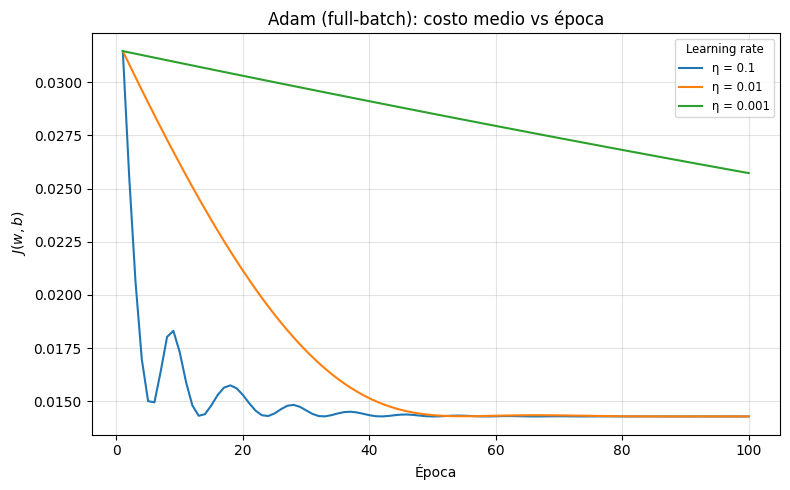

In [136]:
import matplotlib.pyplot as plt
import numpy as np

epocas_eje = np.arange(1, EPOCAS_COMPARATIVA + 1)

plt.figure(figsize=(8, 5))
for _eta in TASAS_APRENDIZAJE:
    plt.plot(
        epocas_eje,
        historiales_J_adam_full_batch[_eta],
        label=f"η = {_eta:g}",
        color=COLORES_LEARNING_RATE[_eta],
    )

plt.xlabel("Época")
plt.ylabel(r"$J(w,b)$")
plt.title("Adam (full-batch): costo medio vs época")
plt.legend(title="Learning rate", fontsize="small", title_fontsize="small")
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

### Optimizador Adam (mini-batch)

La siguiente celda implementa **Adam** recorriendo en cada época los datos en **mini-batches**: se barajan los índices, se parte el conjunto en bloques de tamaño **`TAMANO_MINI_BATCH_ADAM`** (consigna: **≥ 16**) y por cada bloque se calcula el gradiente y se aplica un paso de Adam. El contador \(t\) de la corrección de sesgo **avanza por cada mini-batch**, no por época. **`historial_J[k]`** sigue siendo \(J(w,b)\) sobre **todo** el conjunto al **inicio** de la época \(k\) (igual criterio que GD y Adam full-batch).

**Hiperparámetros:** mismos **`TASAS_APRENDIZAJE`**, **`W_INICIAL`**, **`B_INICIAL`**, **`EPOCAS_COMPARATIVA`** que en los otros optimizadores. Hay un comentario en código que marca **dónde cambiar el tamaño de batch** entre corridas.

**Requisito de datos:** debe cumplirse **`len(_x) >= TAMANO_MINI_BATCH_ADAM`**. Con el dataset sintético del notebook (**`n >= 200`**) se cumple de sobra para un batch de 16 o similar.

</div>

In [137]:
def entrenar_adam_mini_batch(
    x: np.ndarray,
    y: np.ndarray,
    tasa_aprendizaje: float,
    epocas: int,
    tamano_mini_batch: int,
    w_inicial: float | None = None,
    b_inicial: float | None = None,
    beta1: float = 0.9,
    beta2: float = 0.999,
    epsilon: float = 1e-8,
    semilla: int | None = None,
    semilla_barajado: int | None = None,
) -> tuple[float, float, list[float]]:
    """
    Adam con mini-batches: un paso de Adam por cada mini-batch; barajado por época.
    historial_J[k] es J sobre todo el conjunto al inicio de la época k.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = x.size
    if tamano_mini_batch < 16:
        raise ValueError("tamano_mini_batch debe ser >= 16 (consigna).")
    if tamano_mini_batch > m:
        raise ValueError(
            f"tamano_mini_batch ({tamano_mini_batch}) no puede superar el número de muestras ({m})."
        )

    if semilla is not None:
        np.random.seed(semilla)

    if w_inicial is None and b_inicial is None:
        w, b = inicializar_parametros_aleatorios()
    elif w_inicial is None:
        w, b = float(np.random.randn()), float(b_inicial)
    elif b_inicial is None:
        w, b = float(w_inicial), float(np.random.randn())
    else:
        w, b = float(w_inicial), float(b_inicial)

    rng = np.random.default_rng(semilla_barajado) if semilla_barajado is not None else np.random.default_rng()

    m_w = m_b = 0.0
    v_w = v_b = 0.0
    historial_J: list[float] = []
    paso = 0

    for _ in range(epocas):
        historial_J.append(coste_parametros(x, y, w, b))
        indices = np.arange(m)
        rng.shuffle(indices)

        for inicio in range(0, m, tamano_mini_batch):
            idx = indices[inicio : inicio + tamano_mini_batch]
            x_b = x[idx]
            y_b = y[idx]

            paso += 1
            g_w, g_b = gradiente(x_b, y_b, w, b)

            m_w = beta1 * m_w + (1.0 - beta1) * g_w
            m_b = beta1 * m_b + (1.0 - beta1) * g_b
            v_w = beta2 * v_w + (1.0 - beta2) * (g_w**2)
            v_b = beta2 * v_b + (1.0 - beta2) * (g_b**2)

            m_hat_w = m_w / (1.0 - beta1**paso)
            m_hat_b = m_b / (1.0 - beta1**paso)
            v_hat_w = v_w / (1.0 - beta2**paso)
            v_hat_b = v_b / (1.0 - beta2**paso)

            w -= tasa_aprendizaje * m_hat_w / (np.sqrt(v_hat_w) + epsilon)
            b -= tasa_aprendizaje * m_hat_b / (np.sqrt(v_hat_b) + epsilon)

    return w, b, historial_J


# ---------------------------------------------------------------------------
# Ajustar SOLO este valor para distintas corridas (consigna: entero >= 16 y <= n muestras).
# ---------------------------------------------------------------------------
TAMANO_MINI_BATCH_ADAM = 16

historiales_J_adam_mini_batch: dict[float, list[float]] = {}
resultados_entrenamiento_adam_mini_batch: dict[float, tuple[float, float, float, float]] = {}
for _eta in TASAS_APRENDIZAJE:
    _fw, _fb, _hist_mb = entrenar_adam_mini_batch(
        _x,
        _y,
        tasa_aprendizaje=_eta,
        epocas=EPOCAS_COMPARATIVA,
        tamano_mini_batch=TAMANO_MINI_BATCH_ADAM,
        w_inicial=W_INICIAL,
        b_inicial=B_INICIAL,
        semilla=None,
        semilla_barajado=SEMILLA_PARAMETROS_INICIALES,
    )
    historiales_J_adam_mini_batch[_eta] = _hist_mb
    _Jf = coste_parametros(_x, _y, _fw, _fb)
    resultados_entrenamiento_adam_mini_batch[_eta] = (_fw, _fb, _hist_mb[0], _Jf)
    print(
        f"[Adam mini-batch, batch={TAMANO_MINI_BATCH_ADAM}] η = {_eta:g} | J inicio = {_hist_mb[0]:.6f} | J final = {_Jf:.6f} | w, b = {_fw:.6f}, {_fb:.6f}"
    )

[Adam mini-batch, batch=16] η = 0.1 | J inicio = 0.031467 | J final = 0.014320 | w, b = 1.208824, 0.016966
[Adam mini-batch, batch=16] η = 0.01 | J inicio = 0.031467 | J final = 0.014283 | w, b = 1.201663, 0.004682
[Adam mini-batch, batch=16] η = 0.001 | J inicio = 0.031467 | J final = 0.014280 | w, b = 1.204146, 0.000445


<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

### Gráfico: costo \(J(w,b)\) vs época (Adam mini-batch)

Igual que en GD y Adam full-batch: \(J\) frente a la época para cada \(\eta\) en `TASAS_APRENDIZAJE`, usando `historiales_J_adam_mini_batch` obtenido con el tamaño de batch **`TAMANO_MINI_BATCH_ADAM`**. Los **colores** coinciden con **`COLORES_LEARNING_RATE`** (misma \(\eta\) → mismo color que en los gráficos anteriores).

**Resultado esperado:** una figura con tres curvas y leyenda (requiere haber ejecutado sin error la celda de entrenamiento Adam mini-batch).

</div>

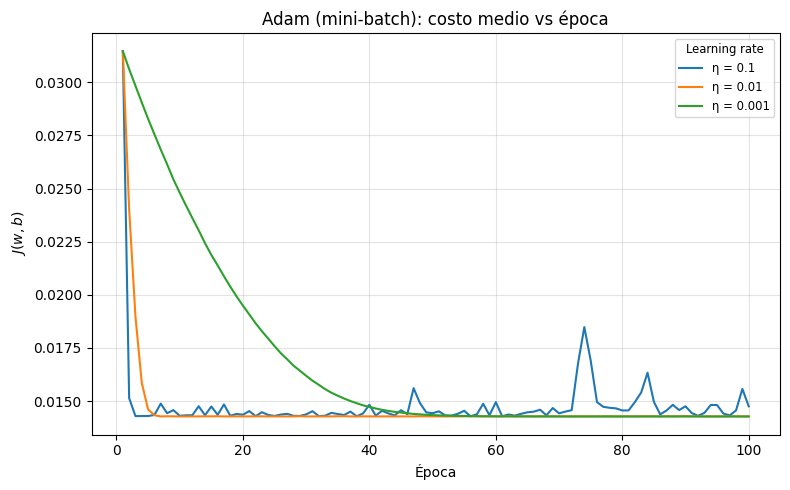

In [138]:
import matplotlib.pyplot as plt
import numpy as np

epocas_eje = np.arange(1, EPOCAS_COMPARATIVA + 1)

plt.figure(figsize=(8, 5))
for _eta in TASAS_APRENDIZAJE:
    plt.plot(
        epocas_eje,
        historiales_J_adam_mini_batch[_eta],
        label=f"η = {_eta:g}",
        color=COLORES_LEARNING_RATE[_eta],
    )

plt.xlabel("Época")
plt.ylabel(r"$J(w,b)$")
plt.title("Adam (mini-batch): costo medio vs época")
plt.legend(title="Learning rate", fontsize="small", title_fontsize="small")
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

### Comparación **por cada learning rate** (consigna)

Según el enunciado del TP: comparar **GD**, **Adam (full-batch)** y **Adam (mini-batch)** **por separado para cada** \(\eta \in\) `TASAS_APRENDIZAJE`, con **gráficas y tablas**. La celda siguiente usa **un subplot por cada \(\eta\)** (tres paneles para las tres tasas definidas), con las tres curvas de costo en cada panel, y luego **una tabla resumen por \(\eta\)** con \(J\) inicial/final y parámetros finales.

**Requisito:** haber ejecutado las celdas de entrenamiento de los tres optimizadores (y la que define `TAMANO_MINI_BATCH_ADAM`).

</div>

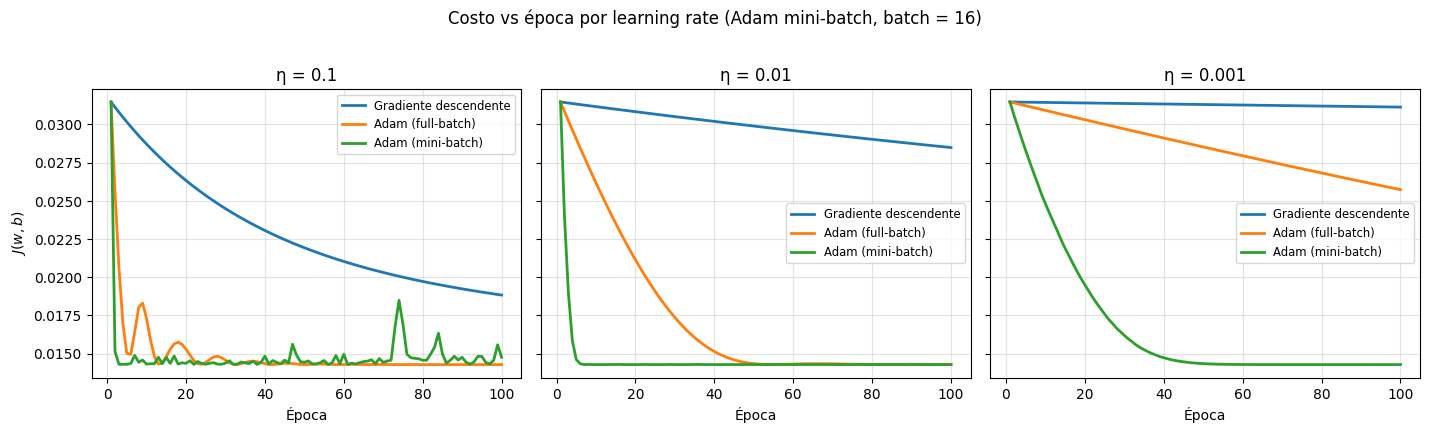

,η,Optimizador,J inicial,J final,w final,b final
0,0.100,Gradiente descendente,0.031467,0.018792,1.658632,0.084866
1,0.100,Adam (full-batch),0.031467,0.014280,1.205941,0.001023
2,0.100,Adam (mini-batch),0.031467,0.014320,1.208824,0.016966
3,0.010,Gradiente descendente,0.031467,0.028456,1.759371,0.345522
4,0.010,Adam (full-batch),0.031467,0.014282,1.210620,0.002765
5,0.010,Adam (mini-batch),0.031467,0.014283,1.201663,0.004682
6,0.001,Gradiente descendente,0.031467,0.031128,1.763715,0.394346
7,0.001,Adam (full-batch),0.031467,0.025674,1.653514,0.302890
8,0.001,Adam (mini-batch),0.031467,0.014280,1.204146,0.000445


In [139]:
import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from IPython.display import display
except ImportError:

    def display(obj):
        print(obj)

epocas_eje = np.arange(1, EPOCAS_COMPARATIVA + 1)
n_eta = len(TASAS_APRENDIZAJE)
fig, axes = plt.subplots(1, n_eta, figsize=(4.8 * n_eta, 4.2), sharey=True)
if n_eta == 1:
    axes = np.array([axes])

for ax, _eta in zip(axes, TASAS_APRENDIZAJE):
    ax.plot(epocas_eje, historiales_J_gd[_eta], label="Gradiente descendente", lw=2)
    ax.plot(epocas_eje, historiales_J_adam_full_batch[_eta], label="Adam (full-batch)", lw=2)
    ax.plot(epocas_eje, historiales_J_adam_mini_batch[_eta], label="Adam (mini-batch)", lw=2)
    ax.set_title(f"η = {_eta:g}")
    ax.set_xlabel("Época")
    ax.grid(True, alpha=0.35)
    ax.legend(fontsize="small", loc="best")

axes[0].set_ylabel(r"$J(w,b)$")
fig.suptitle(
    f"Costo vs época por learning rate (Adam mini-batch, batch = {TAMANO_MINI_BATCH_ADAM})",
    y=1.02,
)
plt.tight_layout()
plt.show()

# --- Tablas: una fila por optimizador, agrupadas por η ---
tabla_filas = []
for _eta in TASAS_APRENDIZAJE:
    wg, bg, Ji_gd, Jf_gd = resultados_entrenamiento_gd[_eta]
    wf, bf, Ji_af, Jf_af = resultados_entrenamiento_adam_full_batch[_eta]
    wm, bm, Ji_am, Jf_am = resultados_entrenamiento_adam_mini_batch[_eta]
    for nombre, Ji, Jf, w, b in (
        ("Gradiente descendente", Ji_gd, Jf_gd, wg, bg),
        ("Adam (full-batch)", Ji_af, Jf_af, wf, bf),
        ("Adam (mini-batch)", Ji_am, Jf_am, wm, bm),
    ):
        tabla_filas.append(
            {
                "η": _eta,
                "Optimizador": nombre,
                "J inicial": Ji,
                "J final": Jf,
                "w final": w,
                "b final": b,
            }
        )

if pd is not None:
    df = pd.DataFrame(tabla_filas)
    display(df)
else:
    for r in tabla_filas:
        print(r)

<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

### \(y(x)\) vs \(\hat{y}(x)\): rejilla **3×3** (consigna)

Se grafica el **dataset sintético** (muestras \(y\) en función de \(x\)) frente a la **salida del modelo** \(\hat{y}=\tanh(wx+b)\) con los **\(w,b\)** finales de cada corrida. La **misma figura** tiene **9 subplots**: **3 filas** (gradiente descendente, Adam full-batch, Adam mini-batch) × **3 columnas** (cada \(\eta\) en `TASAS_APRENDIZAJE`). En gris punteado se repite la **señal determinista sin ruido** usada al armar el dataset, para ver si el modelo recupera un patrón no lineal parecido al elegido.

**Requisito:** celda del dataset (`_x`, `_y`, `A`, `k`, `B`, `omega`), función `forward`, y las tres celdas de entrenamiento con `resultados_entrenamiento_*`.

</div>

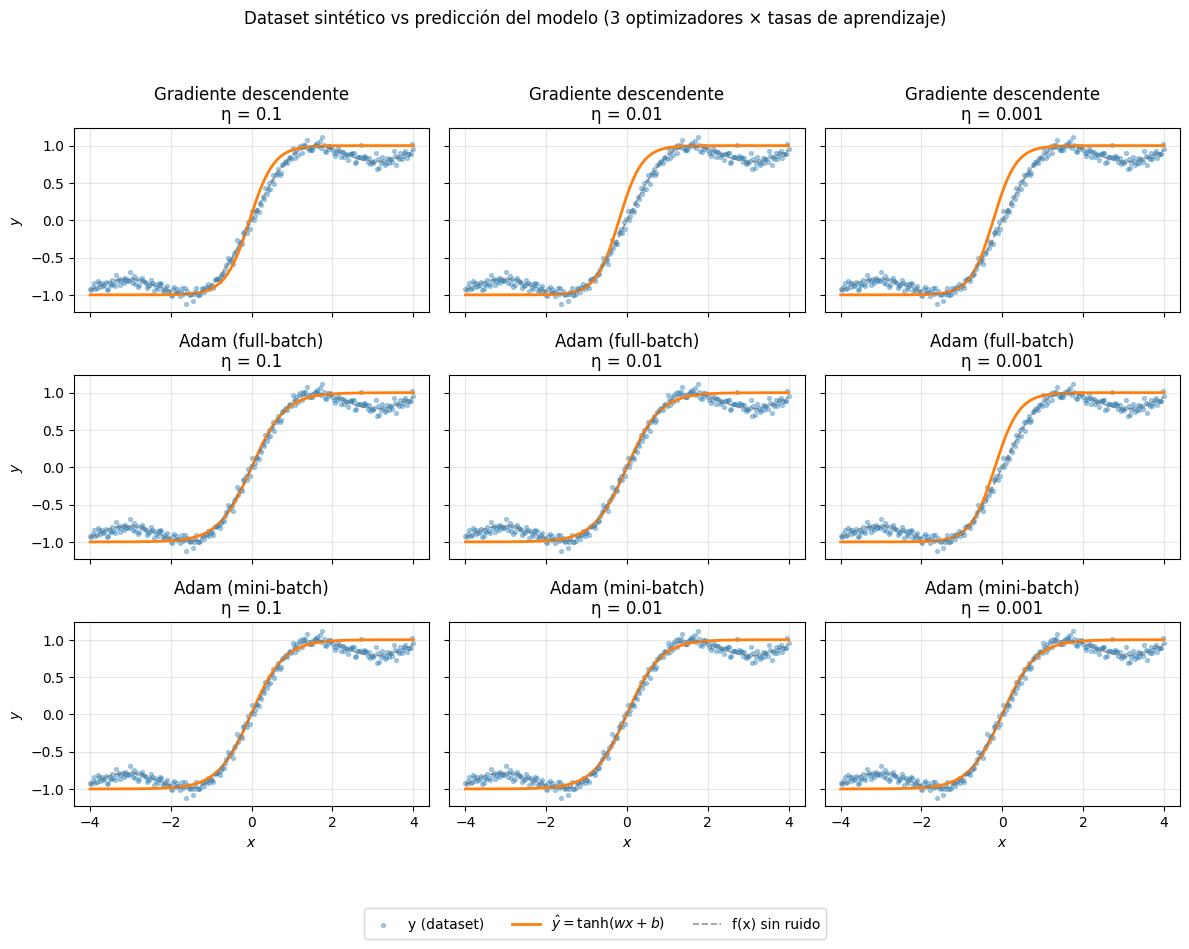

In [140]:
import matplotlib.pyplot as plt
import numpy as np

# Misma señal determinista que en la celda del dataset (patrón no lineal elegido, sin ruido)
_senal_sin_ruido = A * np.tanh(k * _x) + B * np.sin(omega * _x)

_optim_filas = (
    ("Gradiente descendente", resultados_entrenamiento_gd),
    ("Adam (full-batch)", resultados_entrenamiento_adam_full_batch),
    ("Adam (mini-batch)", resultados_entrenamiento_adam_mini_batch),
)

n_col = len(TASAS_APRENDIZAJE)
fig, axes = plt.subplots(3, n_col, figsize=(4.0 * n_col, 9.0), sharex=True, sharey=True)
if n_col == 1:
    axes = axes.reshape(3, 1)

for r, (nombre_opt, res_dict) in enumerate(_optim_filas):
    for c, eta in enumerate(TASAS_APRENDIZAJE):
        ax = axes[r, c]
        w_f, b_f, _, _ = res_dict[eta]
        y_hat = forward(_x, w_f, b_f)
        show_leg = r == 0 and c == 0
        ax.scatter(
            _x,
            _y,
            s=8,
            alpha=0.35,
            c="C0",
            label="y (dataset)" if show_leg else None,
        )
        ax.plot(_x, y_hat, color="C1", lw=2.0, label=r"$\hat{y}=\tanh(wx+b)$" if show_leg else None)
        ax.plot(
            _x,
            _senal_sin_ruido,
            color="gray",
            ls="--",
            lw=1.2,
            alpha=0.85,
            label="f(x) sin ruido" if show_leg else None,
        )
        ax.set_title(f"{nombre_opt}\nη = {eta:g}")
        ax.grid(True, alpha=0.3)

for c in range(n_col):
    axes[-1, c].set_xlabel(r"$x$")
for r in range(3):
    axes[r, 0].set_ylabel(r"$y$")

fig.suptitle(
    "Dataset sintético vs predicción del modelo (3 optimizadores × tasas de aprendizaje)",
    y=1.01,
)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.02), frameon=True)
plt.tight_layout(rect=(0, 0.06, 1, 0.98))
plt.show()

## Conclusiones

- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador. No solo deben comparar el resultado final del costo, sino también la velocidad de convergencia y otros aspectos que consideren relevantes.